# Braking Distance Prediction

Predict braking distance from car speed using Polynomial Regression.

## Import Libraries

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

## Load dataset

In [87]:
data = pd.read_excel('../datasets/regression/braking_distance.xlsx')
data.head()

,Car Speed (km/h),Braking Distance (m),Vehicle Weight (kg),Road Condition,Was it raining?
0,20,7.1,1180,Dry,No
1,25,10.0,1210,Dry,No
2,30,13.8,1090,Wet,Yes
3,35,17.0,1320,Dry,No
4,40,22.1,1260,Dry,No


## Data Overview

In [88]:
print("Shape:", data.shape)
data.info()
print("\nMissing values:")
print(data.isnull().sum())
print("\nDuplicates:", data.duplicated().sum())

Shape: (30, 5)
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Car Speed (km/h)      30 non-null     int64  
 1   Braking Distance (m)  30 non-null     float64
 2   Vehicle Weight (kg)   30 non-null     int64  
 3   Road Condition        30 non-null     str    
 4   Was it raining?       30 non-null     str    
dtypes: float64(1), int64(2), str(2)
memory usage: 1.3 KB

Missing values:
Car Speed (km/h)        0
Braking Distance (m)    0
Vehicle Weight (kg)     0
Road Condition          0
Was it raining?         0
dtype: int64

Duplicates: 0


## Select Variables

In [89]:
X = data[['Car Speed (km/h)']]
y = data['Braking Distance (m)']

In [90]:
print(X.shape)
print(y.shape)

(30, 1)
(30,)


## Split Dataset

In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Polynomial features

In [92]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(
    degree = 2,
    include_bias = False

)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [93]:
print(X_train.shape)
print(X_train_poly.shape)

(24, 1)
(24, 2)


## Train Model

In [94]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_poly, y_train)
print('Model trianed succesfully')

Model trianed succesfully


## Make predictions

In [95]:
y_pred = model.predict(X_test_poly)
y_pred

array([91.09472726,  8.4780516 , 52.51754935, 15.66960553, 47.69779252,
       55.87083939])

## Model Evaluation

In [96]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
polynomial_r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print('Polynomial R² :', polynomial_r2)
print('MAE :', mae)
print('RMSE :', rmse)

Polynomial R² : 0.9997629300619144
MAE : 0.33405250334071707
RMSE : 0.1790713045549975


## Model Comparison

In [97]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear R²:", linear_r2)
print("Polynomial R²:", polynomial_r2)

Linear R²: 0.9433532879237816
Polynomial R²: 0.9997629300619144


## Visaulize Results

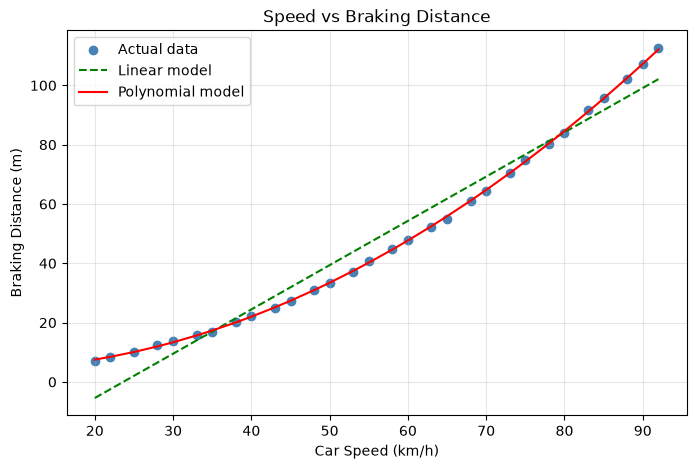

In [98]:
X_sorted = X.sort_values('Car Speed (km/h)')
X_sorted_poly = poly.transform(X_sorted)

plt.figure(figsize=(8, 5))

plt.scatter(
    X['Car Speed (km/h)'],
    y,
    color='steelblue',
    label='Actual data'
)

plt.plot(
    X_sorted['Car Speed (km/h)'],
    linear_model.predict(X_sorted),
    color='green',
    linestyle='--',
    label='Linear model'
)

plt.plot(
    X_sorted['Car Speed (km/h)'],
    model.predict(X_sorted_poly),
    color='red',
    label='Polynomial model'
)

plt.xlabel('Car Speed (km/h)')
plt.ylabel('Braking Distance (m)')
plt.title('Speed vs Braking Distance')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Conclusion

The degree-2 Polynomial Regression model achieved an R² score of approximately 0.9998, compared with approximately 0.9434 for Linear Regression. This shows that braking distance has a curved relationship with speed. Because the dataset contains only 30 observations, the result should be treated as a learning demonstration rather than proof of real-world reliability.